# CSP + LDA on the processed dataset

Loads `dataset_train.npz` / `dataset_test.npz` from `data/processed/`, fits a **CSP** (Common Spatial Patterns) feature extractor and **LDA** classifier in a single pipeline, reports accuracy, then visualizes:

- **CSP spatial filters / patterns** as **channel weight** heatmaps (and bar charts when there are few electrodes) — works from NumPy tensors alone; MNE topomap helpers break for multi-class CSP when `evals_` is unset.
- **Scatter of the CSP feature vectors** actually passed to LDA (log-band-power per component), with points colored by class.

> Run `python scripts/build_dataset.py` from the project root if the NPZ files are missing.

## Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

sys.path.insert(0, "../")

from src.config import CLASS_NAMES, CSP_N_COMPONENTS, CSP_REG
TEST_OUTPUT, TRAIN_OUTPUT = (
    Path("../data/processed/dataset_test.npz"),
    Path("../data/processed/dataset_train.npz"),
)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 160,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 12,
        "legend.fontsize": 10,
        "axes.grid": True,
        "grid.alpha": 0.25,
    }
)

## Load tensors and fit CSP → LDA

In [6]:
def load_npz_split(path: Path) -> tuple[np.ndarray, np.ndarray, dict]:
    if not path.is_file():
        raise FileNotFoundError(f"Missing processed dataset: {path}")
    z = np.load(path, allow_pickle=True)
    X = np.asarray(z["X"], dtype=np.float64)
    y = np.asarray(z["y"]).astype(np.int64).ravel()
    meta = {
        "sfreq": float(np.asarray(z["sfreq"]).squeeze()),
        "ch_names": [str(x) for x in np.asarray(z["ch_names"], dtype=object).ravel()],
        "split": str(np.asarray(z["split"]).ravel()[0]),
        "path": path,
    }
    return X, y, meta


def build_model(*, n_components: int, reg: float | None) -> Pipeline:
    csp = CSP(
        n_components=n_components,
        reg=reg,
        log=True,
        norm_trace=False,
    )
    clf = LinearDiscriminantAnalysis()
    return Pipeline([("csp", csp), ("lda", clf)])


X_train, y_train, train_meta = load_npz_split(TRAIN_OUTPUT)
X_test, y_test, test_meta = load_npz_split(TEST_OUTPUT)
n_c = len(CLASS_NAMES)

print(f"train: {train_meta['path'].name}  X{X_train.shape}  {train_meta['split']}")
print(f"test:  {test_meta['path'].name}   X{X_test.shape}  {test_meta['split']}")
print(
    f"sfreq={train_meta['sfreq']} Hz, {len(train_meta['ch_names'])} channels, {n_c} classes"
)

model = build_model(n_components=CSP_N_COMPONENTS, reg=CSP_REG)
model.fit(X_train, y_train)

y_train_hat = model.predict(X_train)
y_test_hat = model.predict(X_test)
print(f"accuracy  train={accuracy_score(y_train, y_train_hat):.4f}  test={accuracy_score(y_test, y_test_hat):.4f}")

labels = list(range(n_c))
print("\nclassification report (test):\n")
print(
    classification_report(
        y_test,
        y_test_hat,
        labels=labels,
        target_names=list(CLASS_NAMES),
        digits=4,
        zero_division=0,
    )
)
print("confusion matrix (test, rows=true, cols=pred):\n")
print(confusion_matrix(y_test, y_test_hat, labels=labels))

train: dataset_train.npz  X(2615, 4, 1025)  train
test:  dataset_test.npz   X(462, 4, 1025)  test
sfreq=256.0 Hz, 4 channels, 4 classes
Computing rank from data with rank=None
    Using tolerance 3.7e-05 (2.2e-16 eps * 4 dim * 4.1e+10  max singular value)
    Estimated rank (data): 4
    data: rank 4 computed from 4 data channels with 0 projectors
Reducing data rank from 4 -> 4
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
accuracy  train=0.3511  test=0.3182

classification report (test):

                  precision    recall  f1-score   support

  elbow_flex_ext     0.3275    0.5357    0.4065       140
 hand_open_close     0.3197    0.3790    0.3469       124
forearm_sup_pron     0.2750    0.1719    0.2115       128
            rest     0.5000    0.0429    0.0789        70

        accuracy                         0.3182    

## CSP spatial filters and patterns (channel weights)

With **more than two classes**, MNE fits CSP via approximate joint diagonalization and stores **`evals_ = None`**. The current `plot_patterns()` / `plot_filters()` helpers then crash inside `get_spatial_filter_from_estimator` (they always read eigenvalues). Here we plot the same **`filters_` and `patterns_` arrays** that `csp.transform()` uses: rows are the spatial weights over your saved channel names (no `Raw` / sensor positions required).

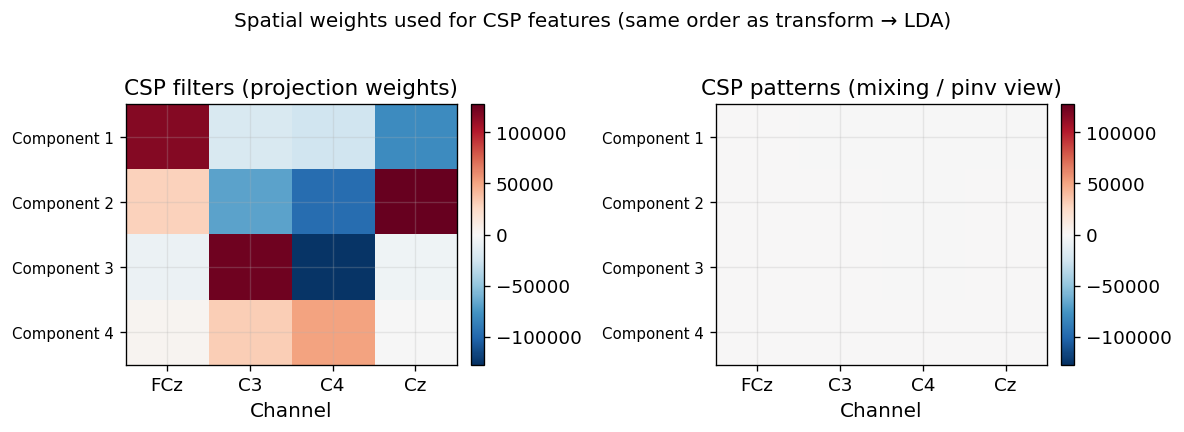

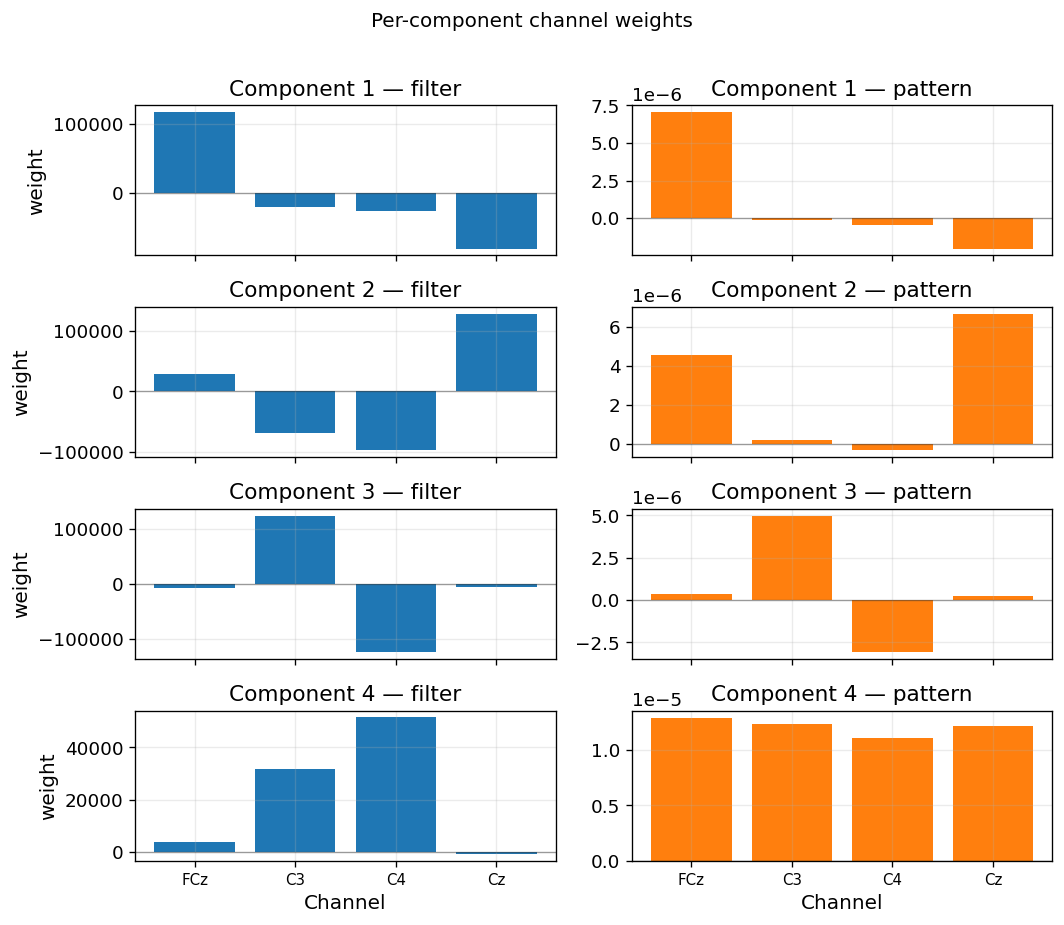

In [7]:
def csp_filter_and_pattern_rows(csp: CSP) -> tuple[np.ndarray, np.ndarray, list[str]]:
    """Match the rows MNE uses in ``csp.transform`` after ``n_components`` selection."""
    n_comp = csp.n_components
    f = csp.filters_
    p = csp.patterns_
    if f is None or p is None:
        raise RuntimeError("CSP is not fitted (missing filters_/patterns_).")

    if f.ndim == 2:
        f_rows = np.asarray(f[:n_comp])
        p_rows = np.asarray(p[:n_comp])
        titles = [f"Component {i + 1}" for i in range(len(f_rows))]
    elif f.ndim == 3:
        # dec_type "multi": (n_classes, n_evecs, n_ch)
        f_rows = f[:, :n_comp, :].reshape(-1, f.shape[-1])
        p_rows = p[:, :n_comp, :].reshape(-1, p.shape[-1])
        classes = getattr(csp, "classes_", np.arange(f.shape[0]))
        titles = [
            f"class {int(classes[c])} · comp {j + 1}"
            for c in range(f.shape[0])
            for j in range(n_comp)
        ]
    else:
        raise ValueError(f"Unexpected filters_.ndim={f.ndim}")

    if p_rows.shape != f_rows.shape:
        raise ValueError(f"Shape mismatch filters {f_rows.shape} vs patterns {p_rows.shape}")
    return f_rows, p_rows, titles


csp = model.named_steps["csp"]
ch_names = train_meta["ch_names"]
filt_rows, pat_rows, comp_titles = csp_filter_and_pattern_rows(csp)
vlim = max(np.nanmax(np.abs(filt_rows)), np.nanmax(np.abs(pat_rows)), 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(10, max(3.5, 0.45 * len(filt_rows))))
for ax, data, title in zip(
    axes,
    (filt_rows, pat_rows),
    ("CSP filters (projection weights)", "CSP patterns (mixing / pinv view)"),
    strict=True,
):
    im = ax.imshow(
        data,
        aspect="auto",
        cmap="RdBu_r",
        vmin=-vlim,
        vmax=vlim,
        interpolation="nearest",
    )
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(comp_titles, fontsize=9)
    ax.set_xticks(range(len(ch_names)))
    ax.set_xticklabels(ch_names)
    ax.set_xlabel("Channel")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle("Spatial weights used for CSP features (same order as transform → LDA)", fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

# Readable channel profiles when there are few electrodes
n_ch = len(ch_names)
if n_ch <= 8 and len(filt_rows) <= 12:
    x = np.arange(n_ch)
    nrows = len(filt_rows)
    fig2, axes2 = plt.subplots(nrows, 2, figsize=(9, 1.9 * nrows), sharex=True)
    if nrows == 1:
        axes2 = axes2.reshape(1, -1)
    for i, title in enumerate(comp_titles):
        axes2[i, 0].bar(x, filt_rows[i], color="C0")
        axes2[i, 0].axhline(0, color="k", linewidth=0.8, alpha=0.35)
        axes2[i, 0].set_ylabel("weight")
        axes2[i, 0].set_title(f"{title} — filter")
        axes2[i, 1].bar(x, pat_rows[i], color="C1")
        axes2[i, 1].axhline(0, color="k", linewidth=0.8, alpha=0.35)
        axes2[i, 1].set_title(f"{title} — pattern")
        for j in range(2):
            axes2[i, j].set_xticks(x)
            axes2[i, j].set_xticklabels(ch_names, fontsize=9)
    axes2[-1, 0].set_xlabel("Channel")
    axes2[-1, 1].set_xlabel("Channel")
    fig2.suptitle("Per-component channel weights", fontsize=12, y=1.01)
    fig2.tight_layout()
    plt.show()

## Features entering LDA

After fitting, `csp.transform(X)` yields the **log variances** of the CSP-projected sources — that is exactly what `LinearDiscriminantAnalysis` sees (when `log=True` in CSP).

Below: **2D scatter** of the first two components on train and test, plus an extra panel if there are at least four components.

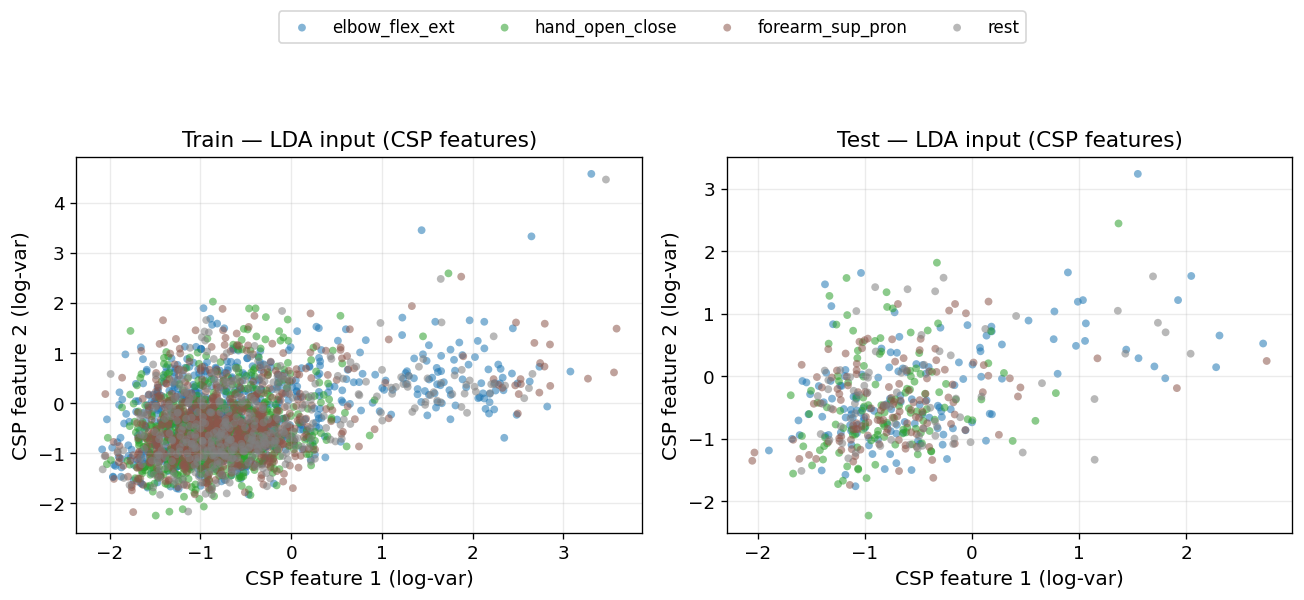

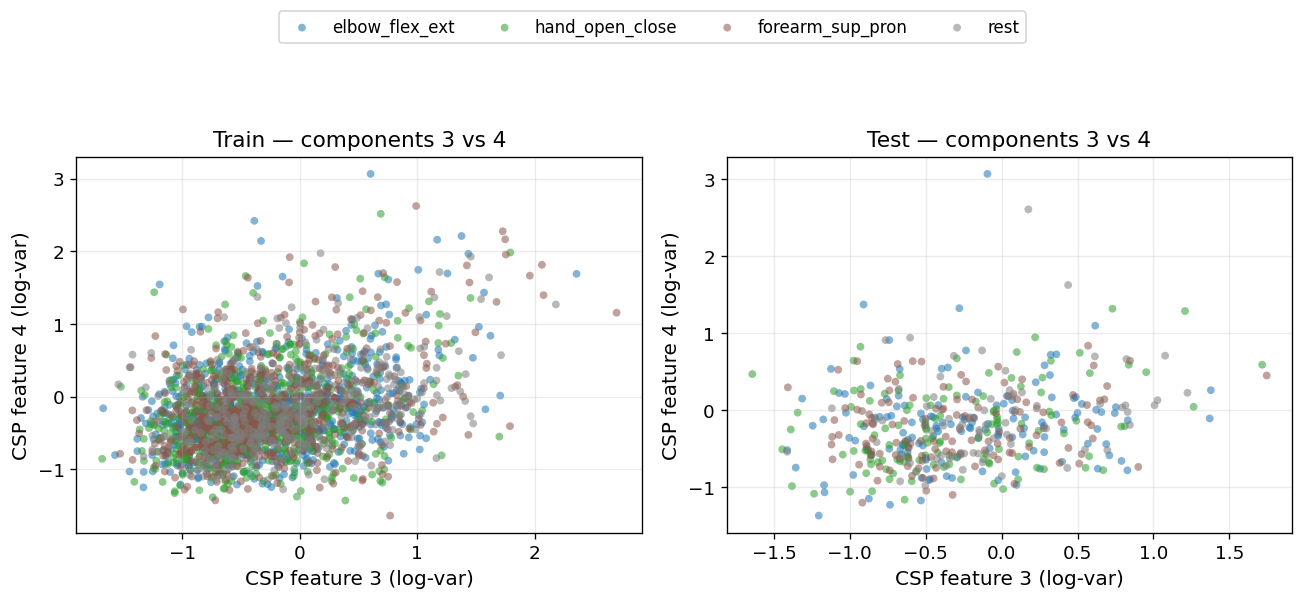

In [8]:
Z_train = csp.transform(X_train)
Z_test = csp.transform(X_test)

colors = plt.cm.tab10(np.linspace(0, 1, n_c, endpoint=False))


def scatter_csp_features(ax, Z, y, title: str, dim_a: int = 0, dim_b: int = 1):
    for k in range(n_c):
        m = y == k
        ax.scatter(
            Z[m, dim_a],
            Z[m, dim_b],
            s=22,
            alpha=0.55,
            c=[colors[k]],
            label=CLASS_NAMES[k],
            edgecolors="none",
        )
    ax.set_xlabel(f"CSP feature {dim_a + 1} (log-var)")
    ax.set_ylabel(f"CSP feature {dim_b + 1} (log-var)")
    ax.set_title(title)


fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=False, sharey=False)
scatter_csp_features(axes[0], Z_train, y_train, "Train — LDA input (CSP features)")
scatter_csp_features(axes[1], Z_test, y_test, "Test — LDA input (CSP features)")
handles, labels_leg = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels_leg,
    loc="upper center",
    ncol=n_c,
    frameon=True,
    bbox_to_anchor=(0.5, 1.12),
)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

if CSP_N_COMPONENTS >= 4:
    fig2, axes2 = plt.subplots(1, 2, figsize=(11, 4.5), sharex=False, sharey=False)
    scatter_csp_features(axes2[0], Z_train, y_train, "Train — components 3 vs 4", dim_a=2, dim_b=3)
    scatter_csp_features(axes2[1], Z_test, y_test, "Test — components 3 vs 4", dim_a=2, dim_b=3)
    fig2.legend(
        handles,
        labels_leg,
        loc="upper center",
        ncol=n_c,
        frameon=True,
        bbox_to_anchor=(0.5, 1.12),
    )
    fig2.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

### 1D marginals for the first CSP feature (per class)

Quick view of **overlap / separation** on the strongest component alone.

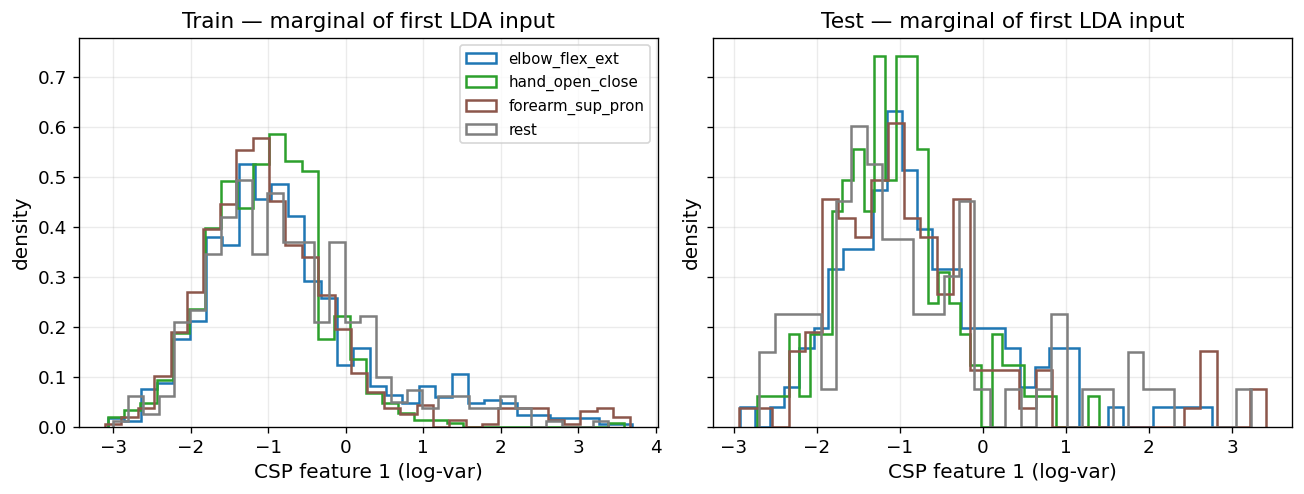

In [5]:
bins = 32
fig, axes = plt.subplots(1, 2, figsize=(11, 4.25), sharey=True)
for ax, split_name, Z, y in (
    (axes[0], "Train", Z_train, y_train),
    (axes[1], "Test", Z_test, y_test),
):
    for k in range(n_c):
        m = y == k
        ax.hist(
            Z[m, 0],
            bins=bins,
            density=True,
            histtype="step",
            linewidth=1.5,
            color=colors[k],
            label=CLASS_NAMES[k],
        )
    ax.set_xlabel("CSP feature 1 (log-var)")
    ax.set_ylabel("density")
    ax.set_title(f"{split_name} — marginal of first LDA input")
axes[0].legend(frameon=True, fontsize=9)
plt.tight_layout()
plt.show()